In [12]:
import numpy as np

def make_pareto_matrix(n_clusters, demes_per_cluster, diag_frac=0.8,
                       within_frac=0.15, between_frac=0.05, seed=0):
    """
    Toy row-stochastic importation matrix built on a Pareto-style principle:
    most of a deme's mass sits on itself (diag_frac), a moderate amount
    stays within its own cluster (within_frac), and only a small remainder
    leaks to other clusters (between_frac). diag_frac + within_frac +
    between_frac should sum to 1.
    """
    rng = np.random.default_rng(seed)
    n = n_clusters * demes_per_cluster
    labels = np.repeat(np.arange(n_clusters), demes_per_cluster)
    A = np.zeros((n, n))

    for i in range(n):
        k = labels[i]
        A[i, i] = diag_frac

        within_demes = np.where((labels == k) & (np.arange(n) != i))[0]
        if len(within_demes) > 0:
            w = rng.random(len(within_demes))
            w = w / w.sum() * within_frac
            A[i, within_demes] = w

        between_demes = np.where(labels != k)[0]
        if len(between_demes) > 0:
            b = rng.random(len(between_demes))
            b = b / b.sum() * between_frac
            A[i, between_demes] = b

    A = A / A.sum(1, keepdims=True)
    return A, labels


# ---- replace real data with toy network ----
n_clusters, demes_per_cluster = 5, 10
A, true_labels = make_pareto_matrix(
    n_clusters, demes_per_cluster,
    diag_frac=0.8, within_frac=0.15, between_frac=0.05, seed=0
)
n_demes = A.shape[0]
Ne = np.random.default_rng(1).uniform(500, 2000, n_demes)

NE_SCALE = Ne.mean() / 5.0
S_SEL    = 0.00

print(f"n_demes = {n_demes}")
print(f"Ne mean = {Ne.mean():.0f}")
print(f"A row sums all 1? {np.allclose(A.sum(1), 1.0)}")

n_demes = 50
Ne mean = 1280
A row sums all 1? True


pi sums to 1? True
Ne_eff = 54654.6


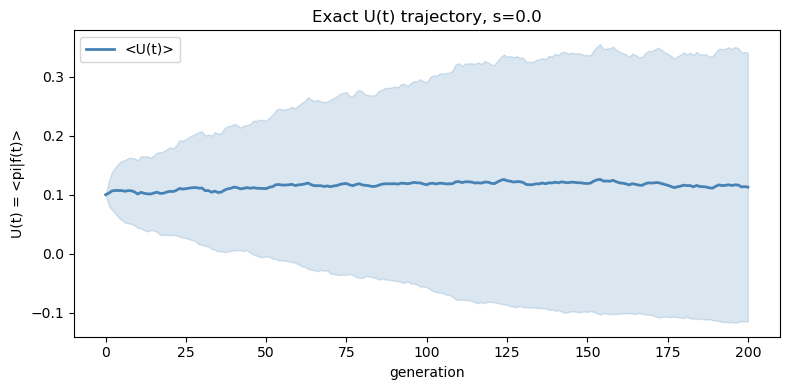


mean increment at s=0: 0.000300  (should be ~0)
var increment at s=0:  0.000447
predicted var (U/Ne_eff): 7.15e-09

mean increment at s=0.0: -0.000515
predicted mean (s*U(1-U) - s*Var_within): 0.000000


In [13]:


# ---- stationary distribution ----
def stationary(A):
    n = A.shape[0]
    M = A.T - np.eye(n); M[-1] = 1.0
    b = np.zeros(n); b[-1] = 1.0
    return np.linalg.solve(M, b)

pi = stationary(A)
print(f"pi sums to 1? {np.allclose(pi.sum(), 1.0)}")

# ---- effective population size ----
Ne_eff = 1.0 / np.sum(pi**2 / Ne)
print(f"Ne_eff = {Ne_eff:.1f}")

# ---- WF helpers ----
def wf_step_sel(p, A, Ne, s):
    pm = A @ p
    pm = np.clip(pm + s * pm * (1 - pm), 0, 1)
    pn = np.zeros_like(p)
    for i in range(len(p)):
        n = max(int(round(Ne[i])), 1)
        pn[i] = np.random.binomial(n, pm[i]) / n
    return pn

def wf_traj_sel(p0, A, Ne, n_steps, s):
    p = p0.copy(); traj = [p.copy()]
    for _ in range(n_steps):
        p = wf_step_sel(p, A, Ne, s)
        traj.append(p.copy())
    return np.array(traj)

# ---- U(t) = <pi|f(t)> from exact full simulation ----
def U_traj(f0_fine, A, Ne, pi, s, n_steps):
    Ne_scaled = Ne / NE_SCALE
    traj = wf_traj_sel(f0_fine, A, Ne_scaled, n_steps, s)
    U = traj @ pi
    return U, traj

# ---- run many simulations and look at U(t) ----
N_STEPS = 200
N_SIMS  = 100
f0_fine = np.full(n_demes, 0.1)

U_runs = []
for _ in range(N_SIMS):
    U, _ = U_traj(f0_fine, A, Ne, pi, S_SEL, N_STEPS)
    U_runs.append(U)
U_runs = np.array(U_runs)

gen = np.arange(N_STEPS + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gen, U_runs.mean(0), lw=2, color="steelblue", label="<U(t)>")
ax.fill_between(gen, U_runs.mean(0)-U_runs.std(0), U_runs.mean(0)+U_runs.std(0),
                color="steelblue", alpha=0.2)
ax.set_xlabel("generation"); ax.set_ylabel("U(t) = <pi|f(t)>")
ax.set_title(f"Exact U(t) trajectory, s={S_SEL}")
ax.legend()
plt.tight_layout(); plt.show()

# ---- check <Udot> = 0 at s=0 ----
increments = []
for _ in range(2000):
    U, _ = U_traj(f0_fine, A, Ne, pi, 0.0, 1)
    increments.append(U[1] - U[0])

print(f"\nmean increment at s=0: {np.mean(increments):.6f}  (should be ~0)")
print(f"var increment at s=0:  {np.var(increments):.6f}")
print(f"predicted var (U/Ne_eff): {f0_fine[0]/(Ne_eff*NE_SCALE):.2e}")

# ---- check selection bias: <Udot> at s>0 ----
def within_var_pi(traj_t, pi):
    """pi-weighted within-network variance of f at a single time point."""
    U_t = np.dot(pi, traj_t)
    return np.dot(pi, traj_t**2) - U_t**2

increments_sel = []
gap_pred = []
for _ in range(2000):
    f0_test = np.full(n_demes, 0.1)
    Ne_scaled = Ne / NE_SCALE
    traj = wf_traj_sel(f0_test, A, Ne_scaled, 1, S_SEL)
    U0 = np.dot(pi, traj[0])
    U1 = np.dot(pi, traj[1])
    increments_sel.append(U1 - U0)
    gap_pred.append(S_SEL * (U0*(1-U0) - within_var_pi(traj[0], pi)))

print(f"\nmean increment at s={S_SEL}: {np.mean(increments_sel):.6f}")
print(f"predicted mean (s*U(1-U) - s*Var_within): {np.mean(gap_pred):.6f}")

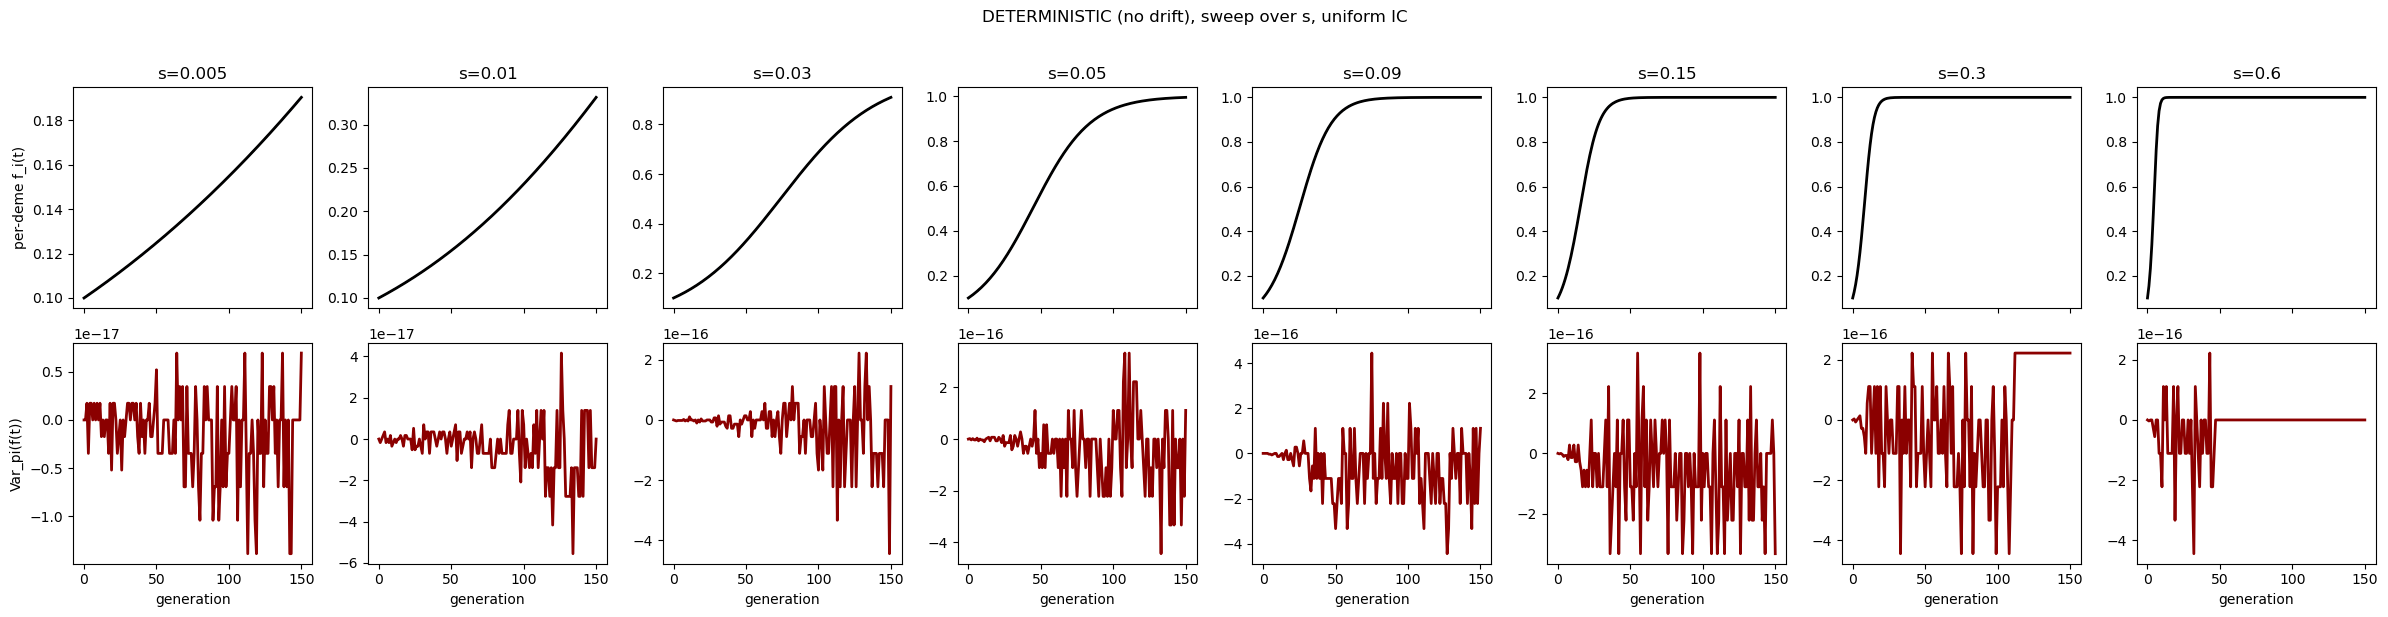

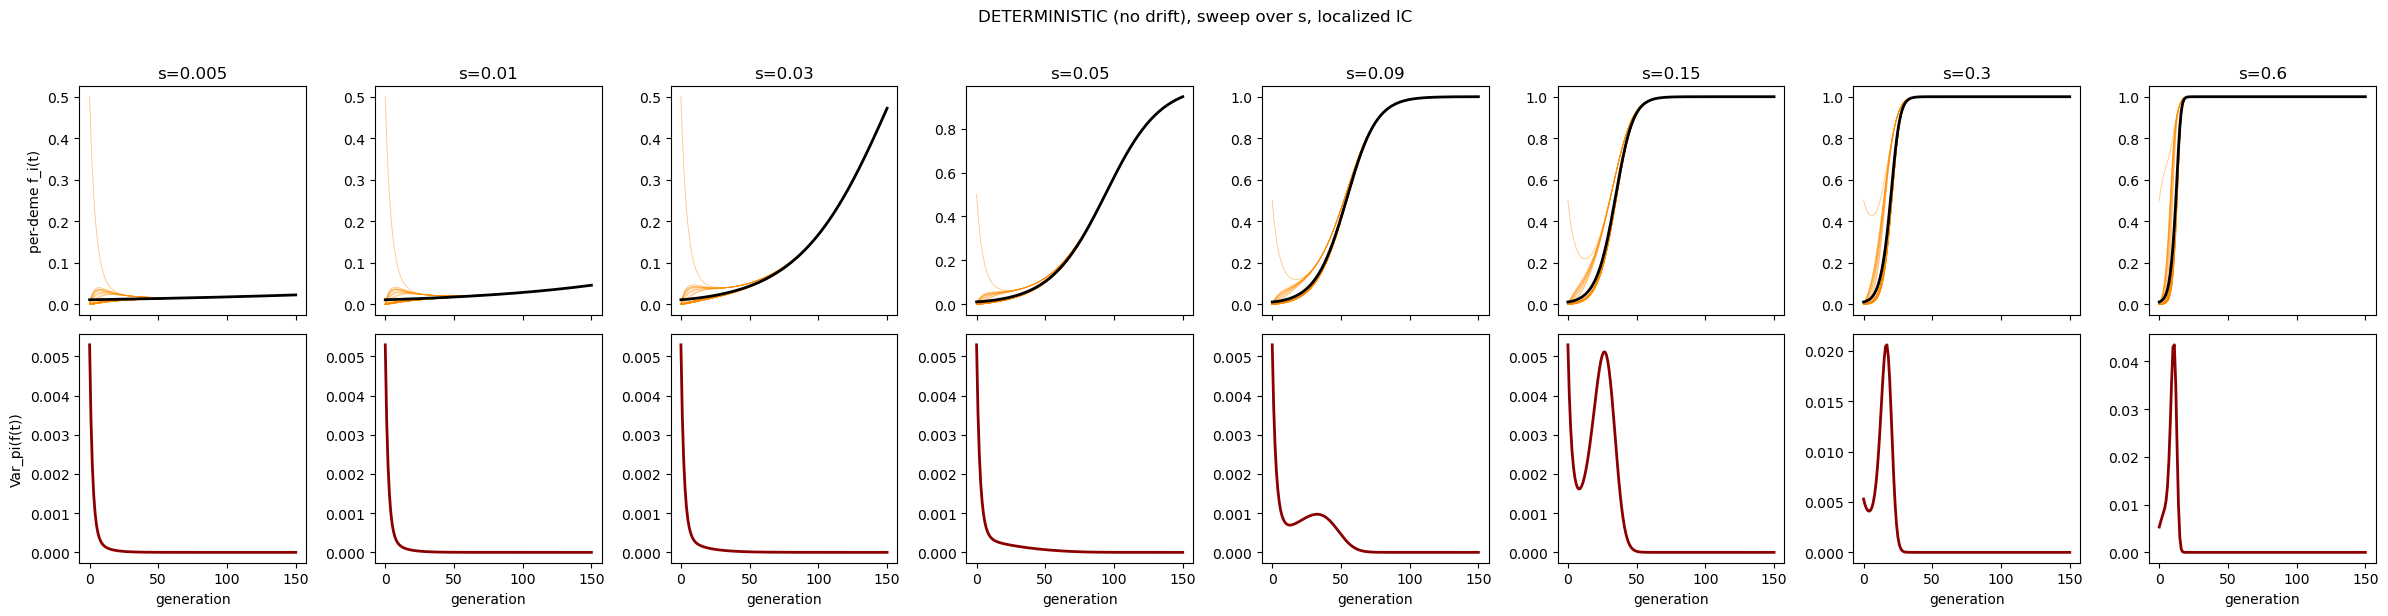

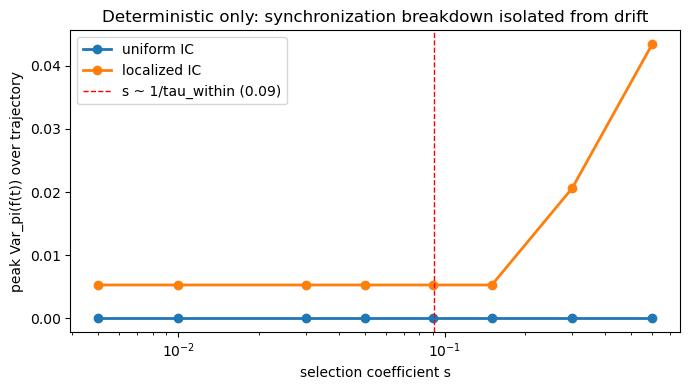

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- deterministic step: migration + selection, NO drift ----
def det_step(f, A, s):
    return np.clip(A @ f + s * f * (1 - f), 0, 1)

def det_traj(f0, A, s, n_steps):
    f = f0.astype(float).copy()
    traj = [f.copy()]
    for _ in range(n_steps):
        f = det_step(f, A, s)
        traj.append(f.copy())
    return np.array(traj)

def var_pi(traj, pi):
    U = traj @ pi
    EF2 = (traj**2) @ pi
    return EF2 - U**2, U

N_STEPS = 150
gen = np.arange(N_STEPS + 1)
s_grid = [0.005, 0.01, 0.03, 0.05, 0.09, 0.15, 0.3, 0.6]

# ============================================================
# SWEEP 1 (deterministic): uniform IC
# ============================================================
f0_uniform = np.full(n_demes, 0.1)

fig, axes = plt.subplots(2, len(s_grid), figsize=(3*len(s_grid), 6), sharex=True)

for col, s_test in enumerate(s_grid):
    traj = det_traj(f0_uniform, A, s_test, N_STEPS)
    var_t, U = var_pi(traj, pi)

    ax = axes[0, col]
    for i in range(n_demes):
        ax.plot(gen, traj[:, i], lw=0.6, alpha=0.5, color="steelblue")
    ax.plot(gen, U, lw=2, color="k")
    ax.set_title(f"s={s_test}")
    if col == 0:
        ax.set_ylabel("per-deme f_i(t)")

    ax2 = axes[1, col]
    ax2.plot(gen, var_t, lw=2, color="darkred")
    ax2.set_xlabel("generation")
    if col == 0:
        ax2.set_ylabel("Var_pi(f(t))")

plt.suptitle("DETERMINISTIC (no drift), sweep over s, uniform IC", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# SWEEP 2 (deterministic): localized IC
# ============================================================
f0_local = np.zeros(n_demes)
f0_local[0] = 0.5

fig, axes = plt.subplots(2, len(s_grid), figsize=(3*len(s_grid), 6), sharex=True)

for col, s_test in enumerate(s_grid):
    traj = det_traj(f0_local, A, s_test, N_STEPS)
    var_t, U = var_pi(traj, pi)

    ax = axes[0, col]
    for i in range(n_demes):
        ax.plot(gen, traj[:, i], lw=0.6, alpha=0.5, color="darkorange")
    ax.plot(gen, U, lw=2, color="k")
    ax.set_title(f"s={s_test}")
    if col == 0:
        ax.set_ylabel("per-deme f_i(t)")

    ax2 = axes[1, col]
    ax2.plot(gen, var_t, lw=2, color="darkred")
    ax2.set_xlabel("generation")
    if col == 0:
        ax2.set_ylabel("Var_pi(f(t))")

plt.suptitle("DETERMINISTIC (no drift), sweep over s, localized IC", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY: peak Var_pi(f) vs s (deterministic, no noise floor)
# ============================================================
peak_var_uniform, peak_var_local = [], []
for s_test in s_grid:
    tu = det_traj(f0_uniform, A, s_test, N_STEPS)
    tl = det_traj(f0_local, A, s_test, N_STEPS)
    vu, _ = var_pi(tu, pi)
    vl, _ = var_pi(tl, pi)
    peak_var_uniform.append(vu.max())
    peak_var_local.append(vl.max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(s_grid, peak_var_uniform, "-o", lw=2, label="uniform IC")
ax.plot(s_grid, peak_var_local, "-o", lw=2, label="localized IC") 
ax.set_xscale("log")
ax.set_xlabel("selection coefficient s")
ax.set_ylabel("peak Var_pi(f(t)) over trajectory")
ax.set_title("Deterministic only: synchronization breakdown isolated from drift")
ax.legend()
plt.tight_layout()
plt.show()

slowest non-trivial mode: tau = 15.59 generations


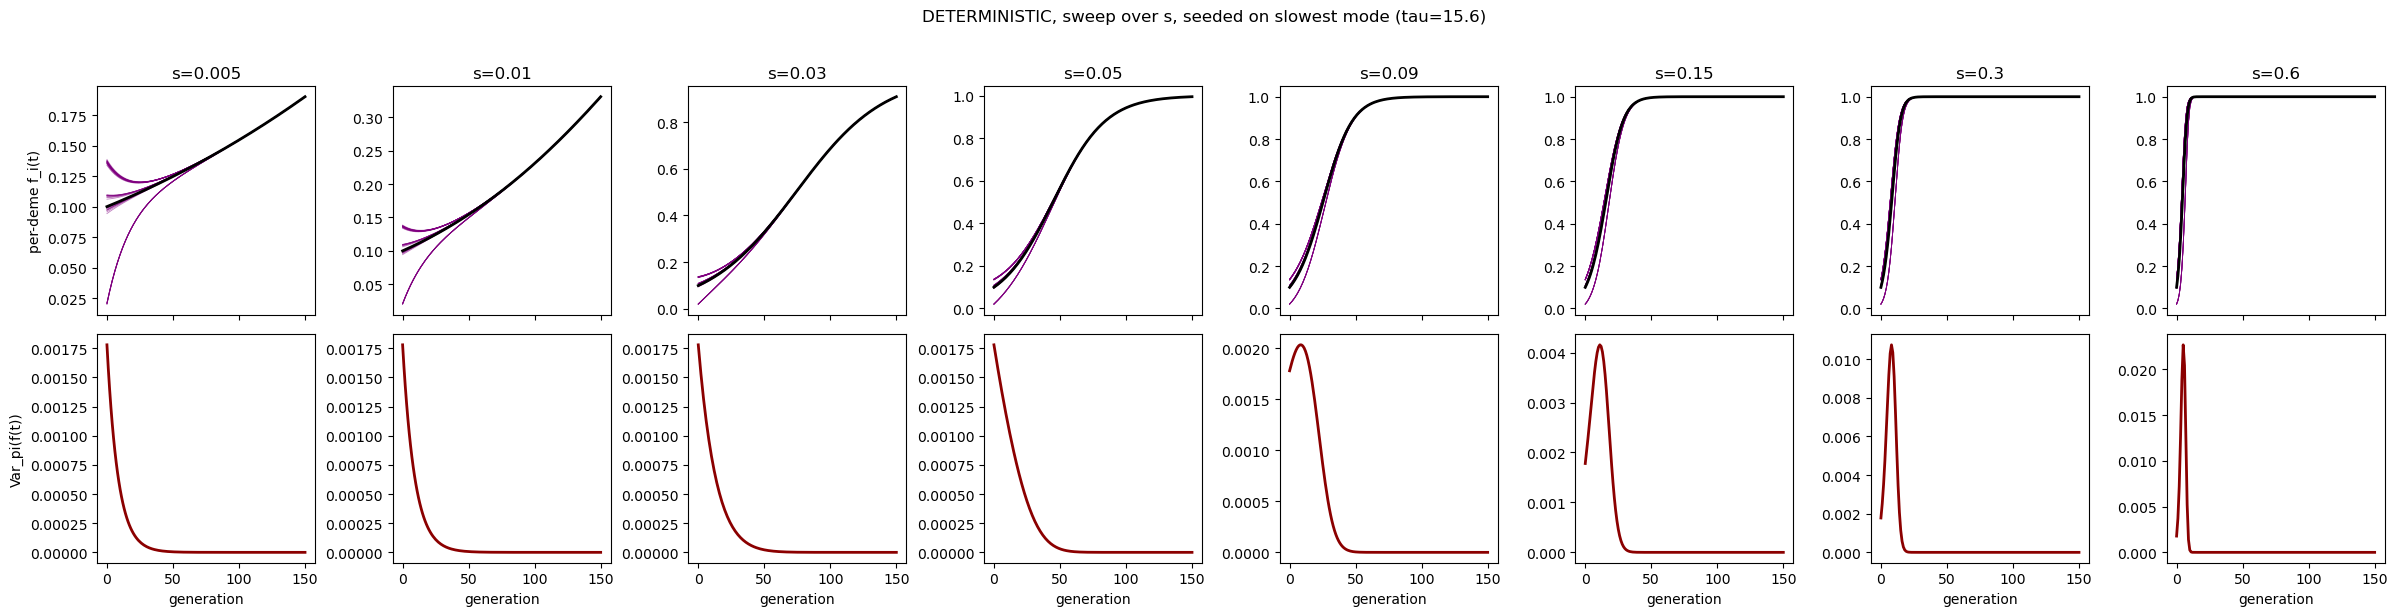

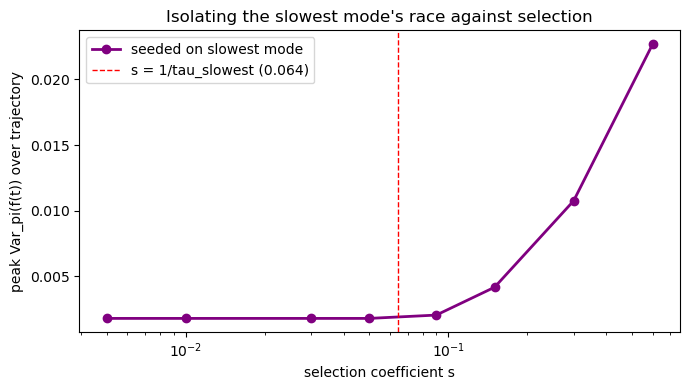

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# seed along the SLOWEST non-trivial eigenmode of A specifically,
# rather than an arbitrary spike that excites all modes including fast ones
lam_A, V_A = np.linalg.eig(A)
order = np.argsort(-np.abs(lam_A))
lam_A, V_A = lam_A[order], V_A[:, order]

v2 = V_A[:, 1].real           # slowest non-trivial mode
v2 = v2 / np.abs(v2).max()    # normalize to [-1, 1]
tau_slowest = -1/np.log(np.abs(lam_A[1]))
print(f"slowest non-trivial mode: tau = {tau_slowest:.2f} generations")

amp = 0.08
f0_mode = np.clip(0.1 + amp * v2, 0.01, 0.99)   # perturb uniform along v2

def det_step(f, A, s):
    return np.clip(A @ f + s * f * (1 - f), 0, 1)

def det_traj(f0, A, s, n_steps):
    f = f0.astype(float).copy()
    traj = [f.copy()]
    for _ in range(n_steps):
        f = det_step(f, A, s)
        traj.append(f.copy())
    return np.array(traj)

def var_pi(traj, pi):
    U = traj @ pi
    EF2 = (traj**2) @ pi
    return EF2 - U**2, U

N_STEPS = 150
gen = np.arange(N_STEPS + 1)
s_grid = [0.005, 0.01, 0.03, 0.05, 0.09, 0.15, 0.3, 0.6]

fig, axes = plt.subplots(2, len(s_grid), figsize=(3*len(s_grid), 6), sharex=True)
for col, s_test in enumerate(s_grid):
    traj = det_traj(f0_mode, A, s_test, N_STEPS)
    var_t, U = var_pi(traj, pi)
    ax = axes[0, col]
    for i in range(n_demes):
        ax.plot(gen, traj[:, i], lw=0.6, alpha=0.5, color="purple")
    ax.plot(gen, U, lw=2, color="k")
    ax.set_title(f"s={s_test}")
    if col == 0: ax.set_ylabel("per-deme f_i(t)")
    ax2 = axes[1, col]
    ax2.plot(gen, var_t, lw=2, color="darkred")
    ax2.set_xlabel("generation")
    if col == 0: ax2.set_ylabel("Var_pi(f(t))")
plt.suptitle(f"DETERMINISTIC, sweep over s, seeded on slowest mode (tau={tau_slowest:.1f})", y=1.02)
plt.tight_layout(); plt.show()

peak_var_mode = []
for s_test in s_grid:
    t = det_traj(f0_mode, A, s_test, N_STEPS)
    v, _ = var_pi(t, pi)
    peak_var_mode.append(v.max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(s_grid, peak_var_mode, "-o", lw=2, color="purple", label="seeded on slowest mode")
ax.axvline(1/tau_slowest, color="r", ls="--", lw=1, label=f"s = 1/tau_slowest ({1/tau_slowest:.3f})")
ax.set_xscale("log")
ax.set_xlabel("selection coefficient s")
ax.set_ylabel("peak Var_pi(f(t)) over trajectory")
ax.set_title("Isolating the slowest mode's race against selection")
ax.legend()
plt.tight_layout(); plt.show()